## Import Libraries

In [40]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Text processing libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully!
Pandas version: 2.0.3
NumPy version: 1.24.3


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HAMZA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HAMZA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HAMZA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Load Dataset

In [41]:
df = pd.read_csv('startups_industry_generated.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


## Data Exploration 

In [42]:
df.head()

,startup_name,company_description,industry,all_tags,batch,status,team_size,country
0,EnigmaTech,Transforming SaaS through subscription and pla...,SaaS,"SaaS, B2B, Enterprise, Cloud Computing",W22,Active,80,JP
1,AxiomSystems,API management and integration platform for mo...,Developer Tools,"Developer Tools, SaaS, B2B, API, Open Source",S19,Inactive,300,SE
2,LumenSphere,Next-generation Artificial Intelligence techno...,Artificial Intelligence,"Artificial Intelligence, Machine Learning, Dee...",W20,Acquired,5,SG
3,EclipseSystems,Innovative Artificial Intelligence startup red...,Artificial Intelligence,"Artificial Intelligence, Machine Learning, Dee...",S21,Active,500,KR
4,FluxBridge,Full-stack SaaS solution for b2b and cloud.,SaaS,"SaaS, B2B, Enterprise, Cloud Computing",W18,Acquired,80,SG


In [47]:
df.shape

(1347, 8)

In [48]:
df.isnull().sum()

startup_name           0
company_description    0
industry               0
all_tags               0
batch                  0
status                 0
team_size              0
country                0
dtype: int64

In [49]:
df.duplicated().sum()

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found.")

No duplicates found.


##  Data Exploration - Industry Distribution


7. Industry Distribution:
industry
Developer Tools            179
SaaS                       178
Artificial Intelligence    139
Insurance                   68
Robotics                    66
Real Estate / Proptech      59
Edtech                      58
Gaming                      55
Biotech                     55
Climate Tech                54
Crypto / Web3               54
Automotive                  52
Logistics                   51
Marketplace                 50
HR Tech                     49
Fintech                     49
Consumer                    48
Media                       44
Health Tech                 39
Name: count, dtype: int64


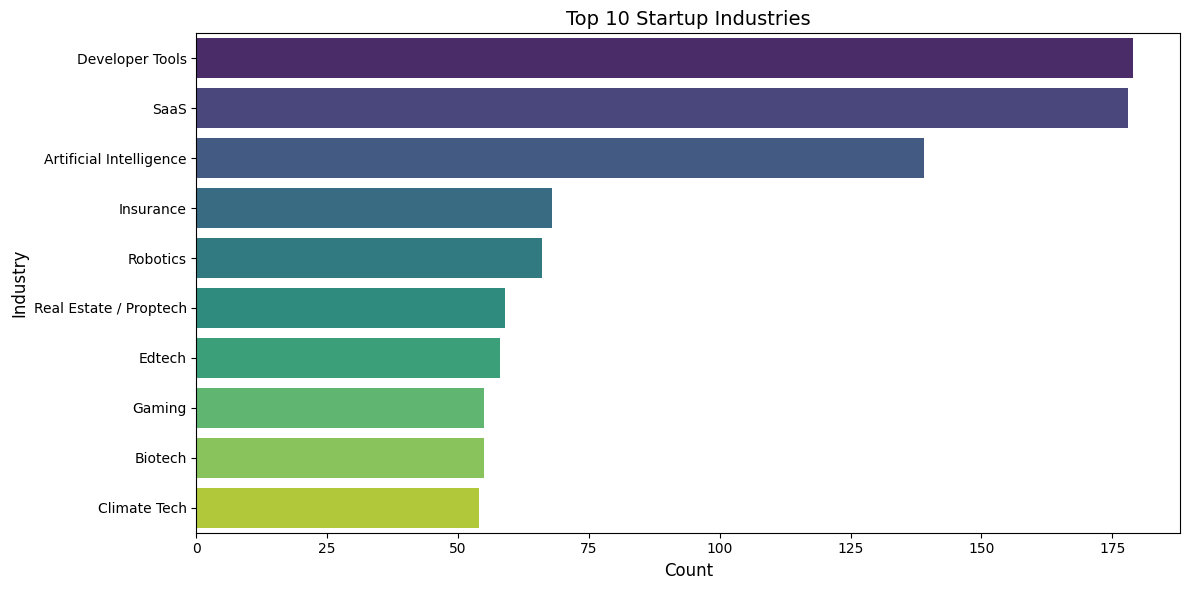


Total unique industries: 19


In [51]:
# 7. Industry distribution
print("\n7. Industry Distribution:")
industry_counts = df['industry'].value_counts()
print(industry_counts)

# Visualize top 10 industries
plt.figure(figsize=(12, 6))
top_industries = industry_counts.head(10)
sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')
plt.title('Top 10 Startup Industries', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Industry', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTotal unique industries: {df['industry'].nunique()}")

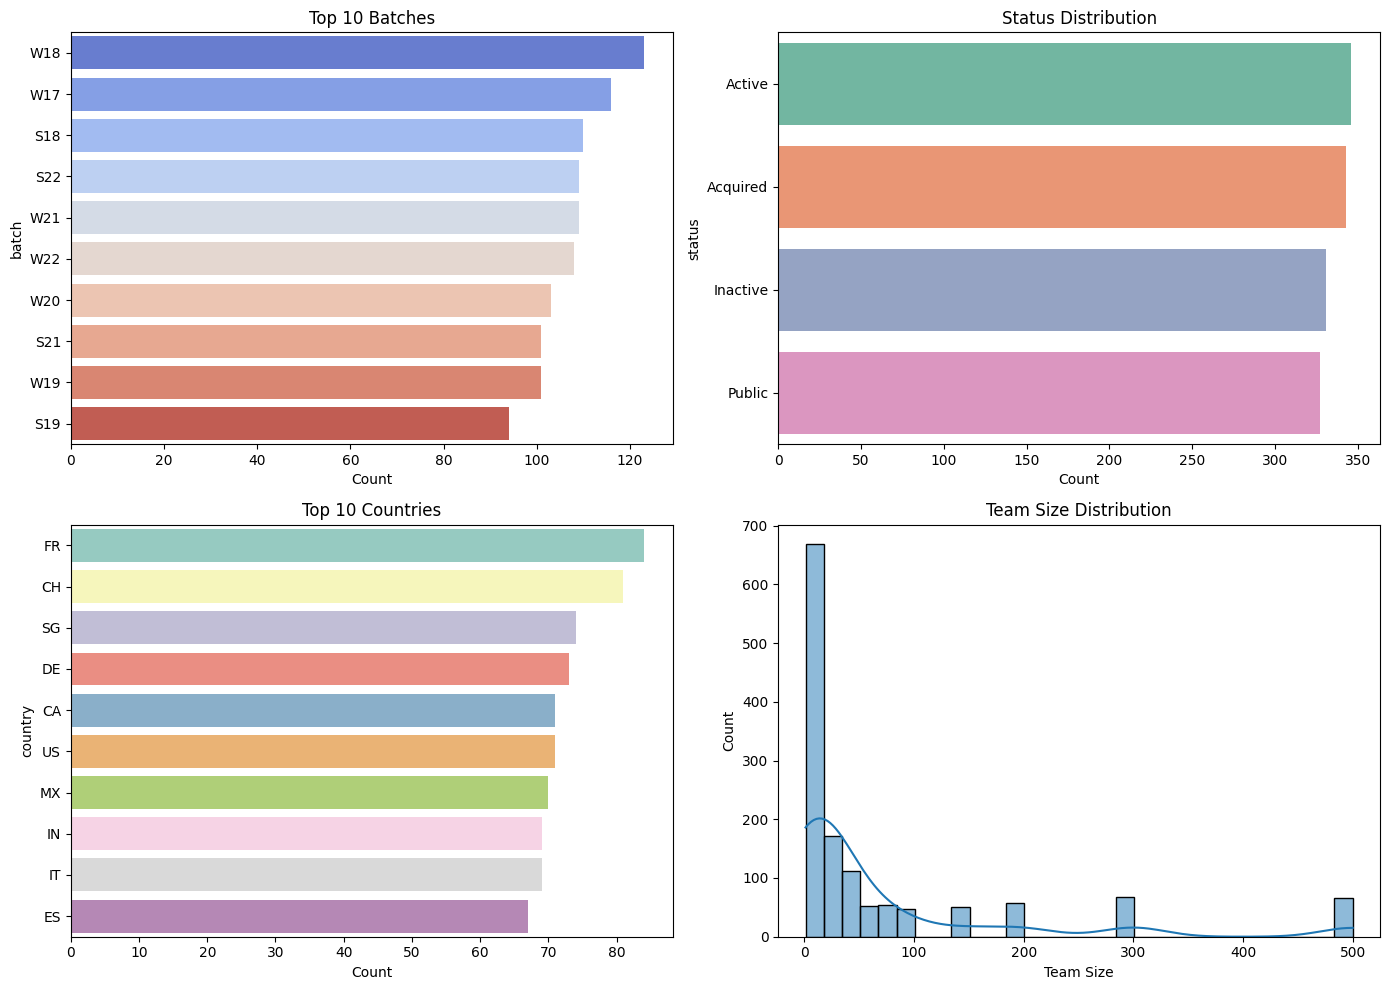

In [52]:
# 8. Explore other features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Batch distribution
batch_counts = df['batch'].value_counts().head(10)
sns.barplot(x=batch_counts.values, y=batch_counts.index, palette='coolwarm', ax=axes[0,0])
axes[0,0].set_title('Top 10 Batches', fontsize=12)
axes[0,0].set_xlabel('Count')

# Status distribution
status_counts = df['status'].value_counts()
sns.barplot(x=status_counts.values, y=status_counts.index, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Status Distribution', fontsize=12)
axes[0,1].set_xlabel('Count')

# Country distribution
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index, palette='Set3', ax=axes[1,0])
axes[1,0].set_title('Top 10 Countries', fontsize=12)
axes[1,0].set_xlabel('Count')

# Team size distribution
sns.histplot(df['team_size'], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title('Team Size Distribution', fontsize=12)
axes[1,1].set_xlabel('Team Size')

plt.tight_layout()
plt.show()

## Text Preprocessing 

In [53]:
print("=" * 60)
print("TASK 2: TEXT PREPROCESSING")
print("=" * 60)

# Function to preprocess text
def preprocess_text(text):
    """
    Preprocess the text by:
    1. Converting to lowercase
    2. Removing punctuation and special characters
    3. Removing stop words
    4. Tokenization
    """
    # Handle NaN or None values
    if isinstance(text, float) or text is None:
        return ""

    # Convert to string
    text = str(text)

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(f'[{string.punctuation}]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 3 & 4. Tokenization and remove stop words
    try:
        tokens = word_tokenize(text)
    except:
        tokens = text.split()

    # Remove stop words and short words
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

    # Join tokens back to text
    return ' '.join(tokens)

print("Preprocessing function defined successfully!")

# Apply preprocessing to company_description
print("\nApplying preprocessing to descriptions...")
df['cleaned_description'] = df['company_description'].apply(preprocess_text)

# Display comparison
print("\nOriginal vs Cleaned Text:")
print("-" * 60)
print(f"Original: {df['company_description'].iloc[0][:100]}...")
print(f"Cleaned:  {df['cleaned_description'].iloc[0][:100]}...")

# Check for empty descriptions
empty_descriptions = df[df['cleaned_description'] == ''].shape[0]
print(f"\nEmpty descriptions after preprocessing: {empty_descriptions}")

# Remove empty descriptions if any
if empty_descriptions > 0:
    df = df[df['cleaned_description'] != '']
    print(f"Removed {empty_descriptions} empty descriptions")
    print(f"New shape: {df.shape}")

# Add word count column
df['word_count'] = df['cleaned_description'].apply(lambda x: len(x.split()))
print(f"\nWord count statistics:")
print(df['word_count'].describe())

TASK 2: TEXT PREPROCESSING
Preprocessing function defined successfully!

Applying preprocessing to descriptions...

Original vs Cleaned Text:
------------------------------------------------------------
Original: Transforming SaaS through subscription and platform....
Cleaned:  transforming saas subscription platform...

Empty descriptions after preprocessing: 0

Word count statistics:
count    1347.000000
mean        5.801039
std         1.205078
min         3.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: word_count, dtype: float64


## Text Preprocessing - Visualization

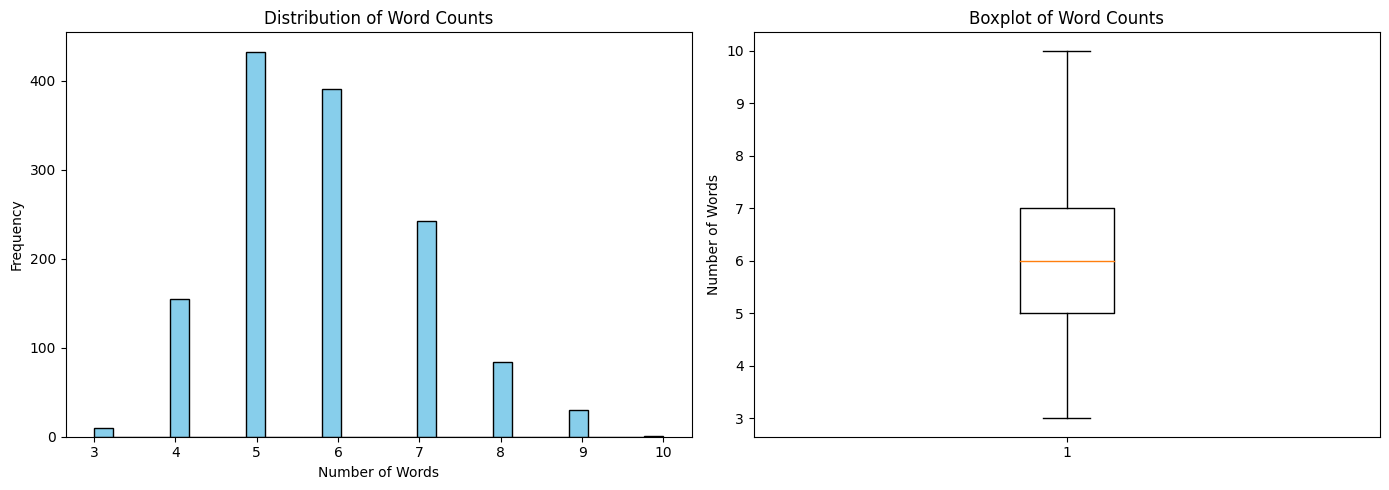


Sample of cleaned descriptions:

1. transforming saas subscription platform...

2. api management integration platform modern software development...

3. nextgeneration artificial intelligence technology chatbot...


In [55]:
# Visualize word count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['word_count'], bins=30, edgecolor='black', color='skyblue')
axes[0].set_title('Distribution of Word Counts', fontsize=12)
axes[0].set_xlabel('Number of Words', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)

# Boxplot
axes[1].boxplot(df['word_count'])
axes[1].set_title('Boxplot of Word Counts', fontsize=12)
axes[1].set_ylabel('Number of Words', fontsize=10)

plt.tight_layout()
plt.show()

# Show sample of cleaned descriptions
print("\nSample of cleaned descriptions:")
for i in range(3):
    print(f"\n{i+1}. {df['cleaned_description'].iloc[i][:150]}...")

##  Feature Engineering 

In [56]:
print("=" * 60)
print("TASK 3: FEATURE ENGINEERING")
print("=" * 60)

# Prepare features and target
X = df['cleaned_description']
y = df['industry']

print(f"Number of samples: {len(X)}")
print(f"Number of unique industries: {len(y.unique())}")

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nNumber of classes: {len(label_encoder.classes_)}")
print(f"Class mapping (first 10):")
for i, cls in enumerate(label_encoder.classes_[:10]):
    print(f"  {i}: {cls}")

TASK 3: FEATURE ENGINEERING
Number of samples: 1347
Number of unique industries: 19

Number of classes: 19
Class mapping (first 10):
  0: Artificial Intelligence
  1: Automotive
  2: Biotech
  3: Climate Tech
  4: Consumer
  5: Crypto / Web3
  6: Developer Tools
  7: Edtech
  8: Fintech
  9: Gaming


## Feature Engineering - TF-IDF Vectorization

In [57]:
# Convert text to numerical features using TF-IDF Vectorization
print("\nApplying TF-IDF Vectorization...")

# Check class distribution for handling rare classes
class_counts = pd.Series(y).value_counts()
print(f"\nClass distribution:")
print(f"  Total classes: {len(class_counts)}")
print(f"  Average samples per class: {class_counts.mean():.2f}")
print(f"  Classes with < 3 samples: {(class_counts < 3).sum()}")

# Keep classes with at least 3 samples for better model performance
min_samples = 3
classes_to_keep = class_counts[class_counts >= min_samples].index

if len(classes_to_keep) < len(class_counts):
    print(f"\nFiltering classes with < {min_samples} samples...")
    df_filtered = df[df['industry'].isin(classes_to_keep)]
    print(f"  Original samples: {len(df)}")
    print(f"  Filtered samples: {len(df_filtered)}")
    print(f"  Classes kept: {len(classes_to_keep)}")

    X = df_filtered['cleaned_description']
    y = df_filtered['industry']

    # Re-encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    print(f"  New number of classes: {len(label_encoder.classes_)}")
else:
    df_filtered = df

# Apply TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    stop_words='english',
    sublinear_tf=True,
    use_idf=True,
    smooth_idf=True
)

X_tfidf = tfidf_vectorizer.fit_transform(X)

print(f"\nTF-IDF matrix shape: {X_tfidf.shape}")
print(f"Number of features: {X_tfidf.shape[1]}")

# Show top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print("\nTop 20 TF-IDF features:")
for i, feature in enumerate(feature_names[:20]):
    print(f"  {i+1}. {feature}")


Applying TF-IDF Vectorization...

Class distribution:
  Total classes: 19
  Average samples per class: 70.89
  Classes with < 3 samples: 0

TF-IDF matrix shape: (1347, 1259)
Number of features: 1259

Top 20 TF-IDF features:
  1. actuarial
  2. actuarial coverage
  3. actuarial insurance
  4. actuarial risk
  5. agriculture
  6. agriculture food
  7. aipowered
  8. aipowered artificial
  9. aipowered automotive
  10. aipowered biotech
  11. aipowered climate
  12. aipowered consumer
  13. aipowered crypto
  14. aipowered developer
  15. aipowered edtech
  16. aipowered fintech
  17. aipowered gaming
  18. aipowered insurance
  19. aipowered logistics
  20. aipowered media


## Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
print("\nSplitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Check class distribution in training set
train_classes, train_counts = np.unique(y_train, return_counts=True)
print(f"\nClass distribution in training (first 10):")
for cls, count in zip(train_classes[:10], train_counts[:10]):
    print(f"  {label_encoder.classes_[cls]}: {count}")

test_classes = np.unique(y_test)
print(f"\nNumber of classes in test set: {len(test_classes)}")
print(f"All test classes in training: {all(cls in train_classes for cls in test_classes)}")


Splitting data into training and testing sets...
Training set size: 1077
Testing set size: 270
Training set shape: (1077, 1259)
Testing set shape: (270, 1259)

Class distribution in training (first 10):
  Artificial Intelligence: 111
  Automotive: 42
  Biotech: 44
  Climate Tech: 43
  Consumer: 39
  Crypto / Web3: 43
  Developer Tools: 143
  Edtech: 47
  Fintech: 39
  Gaming: 44

Number of classes in test set: 19
All test classes in training: True


## Model Training - Logistic Regression

In [59]:
print("=" * 60)
print("TASK 4: MODEL TRAINING")
print("=" * 60)

print("\n" + "=" * 50)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 50)

from sklearn.linear_model import LogisticRegression
import time

# Test different hyperparameters
print("\nTesting different hyperparameters...")
best_lr_f1 = 0
best_lr_model = None
best_lr_params = None

# Test different C values
for c in [0.1, 0.5, 1.0, 2.0, 5.0]:
    try:
        model = LogisticRegression(
            C=c,
            solver='lbfgs',
            max_iter=2000,
            random_state=42,
            multi_class='multinomial',
            class_weight='balanced'
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        print(f"  C={c}: F1-Score={f1:.4f}")

        if f1 > best_lr_f1:
            best_lr_f1 = f1
            best_lr_model = model
            best_lr_params = f"C={c}, class_weight=balanced"

    except Exception as e:
        print(f"  C={c}: Error - {str(e)}")

# Train best model
print(f"\nTraining best Logistic Regression: {best_lr_params}")
lr_model = best_lr_model if best_lr_model is not None else LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=2000,
    random_state=42,
    multi_class='multinomial',
    class_weight='balanced'
)

start_time = time.time()
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - start_time

# Make predictions
lr_pred = lr_model.predict(X_test)

print(f"Training completed in {lr_train_time:.2f} seconds")
print(f"Number of unique predictions: {len(np.unique(lr_pred))}")

TASK 4: MODEL TRAINING

TRAINING LOGISTIC REGRESSION

Testing different hyperparameters...
  C=0.1: F1-Score=0.9927
  C=0.5: F1-Score=0.9889
  C=1.0: F1-Score=0.9889
  C=2.0: F1-Score=0.9926
  C=5.0: F1-Score=0.9888

Training best Logistic Regression: C=0.1, class_weight=balanced
Training completed in 0.06 seconds
Number of unique predictions: 19


## Model Training - Multinomial Naive Bayes

In [60]:
print("\n" + "=" * 50)
print("TRAINING MULTINOMIAL NAIVE BAYES")
print("=" * 50)

from sklearn.naive_bayes import MultinomialNB

# Test different alpha values
print("\nTesting different alpha values...")
best_nb_f1 = 0
best_nb_model = None
best_alpha = None

for alpha in [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    model = MultinomialNB(alpha=alpha, fit_prior=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"  alpha={alpha}: F1-Score={f1:.4f}")

    if f1 > best_nb_f1:
        best_nb_f1 = f1
        best_nb_model = model
        best_alpha = alpha

# Train best model
print(f"\nTraining best Naive Bayes with alpha={best_alpha}")
nb_model = MultinomialNB(alpha=best_alpha if best_alpha else 0.5, fit_prior=True)

start_time = time.time()
nb_model.fit(X_train, y_train)
nb_train_time = time.time() - start_time

# Make predictions
nb_pred = nb_model.predict(X_test)

print(f"Training completed in {nb_train_time:.2f} seconds")
print(f"Number of unique predictions: {len(np.unique(nb_pred))}")


TRAINING MULTINOMIAL NAIVE BAYES

Testing different alpha values...
  alpha=0.001: F1-Score=0.9851
  alpha=0.01: F1-Score=0.9852
  alpha=0.1: F1-Score=0.9851
  alpha=0.5: F1-Score=0.9742
  alpha=1.0: F1-Score=0.9705
  alpha=2.0: F1-Score=0.9295
  alpha=5.0: F1-Score=0.5566
  alpha=10.0: F1-Score=0.2864

Training best Naive Bayes with alpha=0.01
Training completed in 0.00 seconds
Number of unique predictions: 19


## Model Evaluation - Calculate Metrics

In [61]:
print("=" * 60)
print("TASK 5: MODEL EVALUATION")
print("=" * 60)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

def evaluate_model(y_true, y_pred, model_name, train_time):
    """Evaluate model and return metrics"""
    unique_classes = np.unique(y_true)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy:              {accuracy:.4f}")
    print(f"  Precision (macro):     {precision_macro:.4f}")
    print(f"  Precision (weighted):  {precision_weighted:.4f}")
    print(f"  Recall (macro):        {recall_macro:.4f}")
    print(f"  Recall (weighted):     {recall_weighted:.4f}")
    print(f"  F1-Score (macro):      {f1_macro:.4f}")
    print(f"  F1-Score (weighted):   {f1_weighted:.4f}")
    print(f"  Training Time:         {train_time:.2f}s")
    print(f"  Number of classes:     {len(unique_classes)}")

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'precision_weighted': precision_weighted,
        'recall_macro': recall_macro,
        'recall_weighted': recall_weighted,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'train_time': train_time,
        'y_pred': y_pred
    }

# Evaluate both models
lr_results = evaluate_model(y_test, lr_pred, "Logistic Regression", lr_train_time)
nb_results = evaluate_model(y_test, nb_pred, "Multinomial Naive Bayes", nb_train_time)

# Store results
results = {
    'Logistic Regression': lr_results,
    'Multinomial Naive Bayes': nb_results
}

TASK 5: MODEL EVALUATION

Logistic Regression
  Accuracy:              0.9926
  Precision (macro):     0.9900
  Precision (weighted):  0.9933
  Recall (macro):        0.9942
  Recall (weighted):     0.9926
  F1-Score (macro):      0.9917
  F1-Score (weighted):   0.9927
  Training Time:         0.06s
  Number of classes:     19

Multinomial Naive Bayes
  Accuracy:              0.9852
  Precision (macro):     0.9837
  Precision (weighted):  0.9862
  Recall (macro):        0.9848
  Recall (weighted):     0.9852
  F1-Score (macro):      0.9836
  F1-Score (weighted):   0.9852
  Training Time:         0.00s
  Number of classes:     19


## Model Evaluation - Classification Reports

In [ ]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORTS")
print("=" * 60)

# Get unique classes in test set
unique_test_classes = np.unique(y_test)
test_class_names = [label_encoder.classes_[i] for i in unique_test_classes]

print(f"\nClasses in test set: {len(unique_test_classes)}")

print("\n" + "="*40)
print("LOGISTIC REGRESSION CLASSIFICATION REPORT")
print("="*40)
print(classification_report(
    y_test,
    lr_pred,
    labels=unique_test_classes,
    target_names=test_class_names,
    zero_division=0
))

print("\n" + "="*40)
print("NAIVE BAYES CLASSIFICATION REPORT")
print("="*40)
print(classification_report(
    y_test,
    nb_pred,
    labels=unique_test_classes,
    target_names=test_class_names,
    zero_division=0
))


CLASSIFICATION REPORTS

Classes in test set: 19

LOGISTIC REGRESSION CLASSIFICATION REPORT
                         precision    recall  f1-score   support

Artificial Intelligence       1.00      1.00      1.00        28
             Automotive       1.00      1.00      1.00        10
                Biotech       1.00      1.00      1.00        11
           Climate Tech       1.00      1.00      1.00        11
               Consumer       1.00      1.00      1.00         9
          Crypto / Web3       1.00      1.00      1.00        11
        Developer Tools       1.00      1.00      1.00        36
                 Edtech       1.00      1.00      1.00        11
                Fintech       1.00      1.00      1.00        10
                 Gaming       1.00      1.00      1.00        11
                HR Tech       1.00      1.00      1.00        10
            Health Tech       1.00      1.00      1.00         8
              Insurance       1.00      1.00      1.00        

## Confusion Matrix


CONFUSION MATRICES (TOP 10 CLASSES)


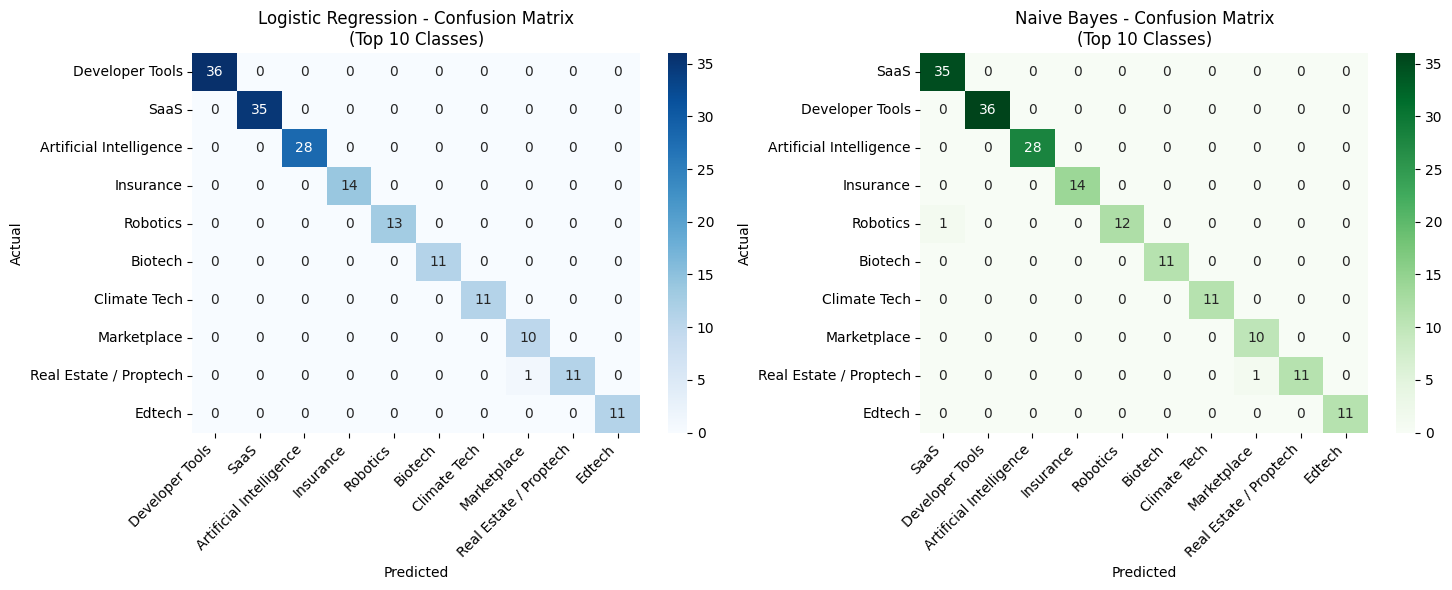

In [63]:
print("\n" + "=" * 60)
print("CONFUSION MATRICES (TOP 10 CLASSES)")
print("=" * 60)

# Function to get top N predicted classes
def get_top_predictions(y_pred, n=10):
    pred_counts = pd.Series(y_pred).value_counts()
    return pred_counts.head(n).index.tolist()

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Get top 10 predicted classes
top_10_lr = get_top_predictions(lr_pred, min(10, len(np.unique(lr_pred))))
top_10_nb = get_top_predictions(nb_pred, min(10, len(np.unique(nb_pred))))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
cm_lr_subset = cm_lr[np.ix_(top_10_lr, top_10_lr)]
sns.heatmap(cm_lr_subset, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_encoder.classes_[i] for i in top_10_lr],
            yticklabels=[label_encoder.classes_[i] for i in top_10_lr], ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix\n(Top 10 Classes)', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=10)
axes[0].set_ylabel('Actual', fontsize=10)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.setp(axes[0].yaxis.get_majorticklabels(), rotation=0)

# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred)
cm_nb_subset = cm_nb[np.ix_(top_10_nb, top_10_nb)]
sns.heatmap(cm_nb_subset, annot=True, fmt='d', cmap='Greens',
            xticklabels=[label_encoder.classes_[i] for i in top_10_nb],
            yticklabels=[label_encoder.classes_[i] for i in top_10_nb], ax=axes[1])
axes[1].set_title('Naive Bayes - Confusion Matrix\n(Top 10 Classes)', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('Actual', fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.setp(axes[1].yaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Model Comparison


MODEL COMPARISON
                  Model  Accuracy  Precision (weighted)  Recall (weighted)  F1-Score (weighted)  F1-Score (macro)  Training Time (s)
    Logistic Regression  0.992593              0.993300           0.992593             0.992672          0.991694           0.061704
Multinomial Naive Bayes  0.985185              0.986229           0.985185             0.985207          0.983592           0.002496


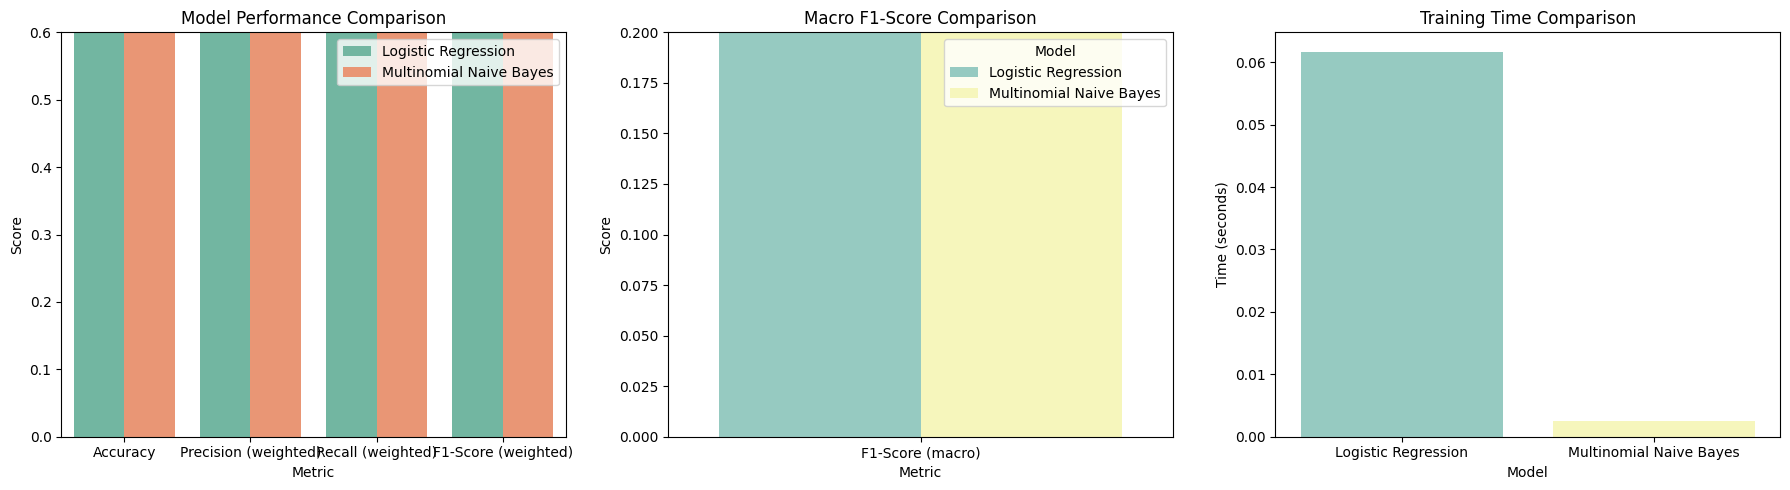


🏆 BEST PERFORMING MODEL: Logistic Regression
   F1-Score (weighted): 0.9927
   Accuracy:            0.9926


In [65]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes'],
    'Accuracy': [lr_results['accuracy'], nb_results['accuracy']],
    'Precision (weighted)': [lr_results['precision_weighted'], nb_results['precision_weighted']],
    'Recall (weighted)': [lr_results['recall_weighted'], nb_results['recall_weighted']],
    'F1-Score (weighted)': [lr_results['f1_weighted'], nb_results['f1_weighted']],
    'F1-Score (macro)': [lr_results['f1_macro'], nb_results['f1_macro']],
    'Training Time (s)': [lr_results['train_time'], nb_results['train_time']]
})

print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Performance metrics
metrics_to_plot = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)']
comparison_melted = comparison_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)
comparison_melted = comparison_melted[comparison_melted['Metric'].isin(metrics_to_plot)]

sns.barplot(
    data=comparison_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Model Performance Comparison', fontsize=12)
axes[0].set_ylim(0, 0.6)
axes[0].legend(loc='upper right')

# Macro metrics
macro_metrics = ['F1-Score (macro)']
comparison_macro = comparison_df.melt(
    id_vars=['Model'],
    var_name='Metric',
    value_name='Score'
)
comparison_macro = comparison_macro[comparison_macro['Metric'].isin(macro_metrics)]

sns.barplot(
    data=comparison_macro,
    x='Metric',
    y='Score',
    hue='Model',
    palette='Set3',
    ax=axes[1]
)
axes[1].set_title('Macro F1-Score Comparison', fontsize=12)
axes[1].set_ylim(0, 0.2)

# Time comparison
sns.barplot(
    data=comparison_df,
    x='Model',
    y='Training Time (s)',
    palette='Set3',
    ax=axes[2]
)
axes[2].set_title('Training Time Comparison', fontsize=12)
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

# Determine best model
lr_f1 = lr_results['f1_weighted']
nb_f1 = nb_results['f1_weighted']

best_model_name = 'Logistic Regression' if lr_f1 > nb_f1 else 'Multinomial Naive Bayes'
best_model = lr_model if lr_f1 > nb_f1 else nb_model
best_y_pred = lr_pred if lr_f1 > nb_f1 else nb_pred

print(f"\n{'='*50}")
print(f"🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"   F1-Score (weighted): {max(lr_f1, nb_f1):.4f}")
print(f"   Accuracy:            {max(lr_results['accuracy'], nb_results['accuracy']):.4f}")
print(f"{'='*50}")

## Feature Importance Analysis


FEATURE IMPORTANCE ANALYSIS (LOGISTIC REGRESSION)

Top 15 Most Predictive Features (Positive):
  tech: 0.0000
  biotech: 0.0000
  platform: 0.0000
  gaming: 0.0000
  transportation: 0.0000
  game: 0.0000
  automotive: 0.0000
  recruiting: 0.0000
  vehicle: 0.0000
  saas company: 0.0000
  shopping: 0.0000
  crypto: 0.0000
  automotive platform: 0.0000
  startup: 0.0000
  crypto web: 0.0000


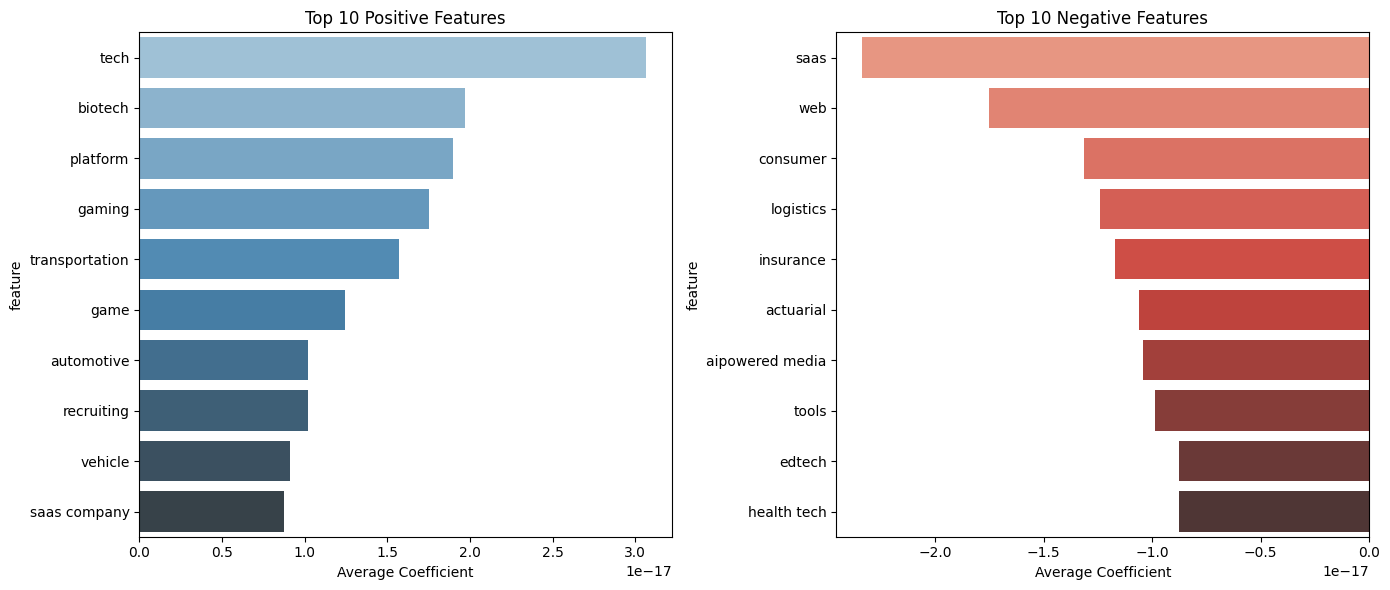

In [66]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS (LOGISTIC REGRESSION)")
print("=" * 60)

feature_names = tfidf_vectorizer.get_feature_names_out()

# Get average coefficients
if len(lr_model.coef_) > 1:
    avg_coef = lr_model.coef_.mean(axis=0)
else:
    avg_coef = lr_model.coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': avg_coef
})

# Top positive features
top_positive = feature_importance.nlargest(15, 'coefficient')
print("\nTop 15 Most Predictive Features (Positive):")
for idx, row in top_positive.iterrows():
    print(f"  {row['feature']}: {row['coefficient']:.4f}")

# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive features
sns.barplot(data=top_positive.head(10), x='coefficient', y='feature', palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 10 Positive Features', fontsize=12)
axes[0].set_xlabel('Average Coefficient', fontsize=10)

# Negative features
top_negative = feature_importance.nsmallest(10, 'coefficient')
sns.barplot(data=top_negative, x='coefficient', y='feature', palette='Reds_d', ax=axes[1])
axes[1].set_title('Top 10 Negative Features', fontsize=12)
axes[1].set_xlabel('Average Coefficient', fontsize=10)

plt.tight_layout()
plt.show()

## Predict New Descriptions

In [67]:
print("\n" + "=" * 60)
print("PREDICTING NEW STARTUP INDUSTRIES")
print("=" * 60)

def predict_industry(description, model=None, vectorizer=None, encoder=None):
    """
    Predict the industry of a startup based on its description.
    """
    if model is None:
        model = best_model
    if vectorizer is None:
        vectorizer = tfidf_vectorizer
    if encoder is None:
        encoder = label_encoder

    # Preprocess the description
    cleaned = preprocess_text(description)

    # Vectorize using TF-IDF
    tfidf_vector = vectorizer.transform([cleaned])

    # Make prediction
    pred_encoded = model.predict(tfidf_vector)
    pred_industry = encoder.inverse_transform(pred_encoded)

    # Get prediction probabilities
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(tfidf_vector)
        top_indices = np.argsort(probs[0])[-5:][::-1]
        top_probs = [(encoder.classes_[i], probs[0][i]) for i in top_indices]
    else:
        top_probs = []

    return pred_industry[0], top_probs

# Test descriptions
test_descriptions = [
    "A SaaS platform for automating customer support using AI and machine learning.",
    "Developing novel therapeutics for cancer treatment using CRISPR gene editing.",
    "A fintech company offering digital banking solutions for small businesses.",
    "Building autonomous drones for last-mile delivery and logistics.",
    "Renewable energy solutions for sustainable future with solar panel technology.",
    "E-commerce platform for handmade crafts and artisanal products.",
    "AI-powered chatbot for healthcare providers to improve patient engagement.",
    "Sustainable packaging solutions made from biodegradable materials.",
    "Cybersecurity platform for protecting IoT devices from cyber threats.",
    "Cloud-based project management software for remote teams."
]

print(f"\nPredictions using {best_model_name}:")
print("-" * 70)

for i, desc in enumerate(test_descriptions, 1):
    pred, probs = predict_industry(desc)
    print(f"\n{i}. Description: {desc[:60]}...")
    print(f"   Predicted Industry: {pred}")
    if probs and len(probs) > 1:
        print("   Top 3 Predictions:")
        for industry, prob in probs[:3]:
            print(f"     - {industry}: {prob:.2%}")


PREDICTING NEW STARTUP INDUSTRIES

Predictions using Logistic Regression:
----------------------------------------------------------------------

1. Description: A SaaS platform for automating customer support using AI and...
   Predicted Industry: SaaS
   Top 3 Predictions:
     - SaaS: 7.70%
     - Artificial Intelligence: 6.97%
     - Biotech: 6.12%

2. Description: Developing novel therapeutics for cancer treatment using CRI...
   Predicted Industry: Biotech
   Top 3 Predictions:
     - Biotech: 8.64%
     - Consumer: 5.46%
     - SaaS: 5.25%

3. Description: A fintech company offering digital banking solutions for sma...
   Predicted Industry: Fintech
   Top 3 Predictions:
     - Fintech: 11.34%
     - Marketplace: 5.22%
     - Logistics: 5.17%

4. Description: Building autonomous drones for last-mile delivery and logist...
   Predicted Industry: Logistics
   Top 3 Predictions:
     - Logistics: 13.45%
     - Robotics: 6.31%
     - Developer Tools: 5.02%

5. Description: Renewabl

## Save Best Models

In [68]:
print("\n" + "=" * 60)
print("SAVING MODELS")
print("=" * 60)

import joblib
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save models
try:
    joblib.dump(lr_model, 'models/logistic_regression_model.joblib')
    joblib.dump(nb_model, 'models/naive_bayes_model.joblib')
    joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.joblib')
    joblib.dump(label_encoder, 'models/label_encoder.joblib')

    # Save best model info
    with open('models/best_model_info.txt', 'w') as f:
        f.write("="*50 + "\n")
        f.write("STARTUP INDUSTRY CLASSIFICATION - BEST MODEL\n")
        f.write("="*50 + "\n\n")
        f.write(f"Best Model: {best_model_name}\n")
        f.write(f"Number of Classes: {len(label_encoder.classes_)}\n")
        f.write(f"TF-IDF Features: {X_tfidf.shape[1]}\n")
        f.write(f"Training Samples: {X_train.shape[0]}\n")
        f.write(f"Testing Samples: {X_test.shape[0]}\n")
        f.write(f"Test Accuracy: {max(lr_results['accuracy'], nb_results['accuracy']):.4f}\n")
        f.write(f"Test F1-Score (weighted): {max(lr_f1, nb_f1):.4f}\n\n")
        f.write("Model Performance:\n")
        f.write(f"  Logistic Regression F1-Score: {lr_results['f1_weighted']:.4f}\n")
        f.write(f"  Naive Bayes F1-Score: {nb_results['f1_weighted']:.4f}\n")
        f.write("\n" + "="*50 + "\n")

    print("✅ Models saved successfully in 'models/' directory")
    print("  📁 logistic_regression_model.joblib")
    print("  📁 naive_bayes_model.joblib")
    print("  📁 tfidf_vectorizer.joblib")
    print("  📁 label_encoder.joblib")
    print("  📄 best_model_info.txt")

except Exception as e:
    print(f"❌ Error saving models: {str(e)}")


SAVING MODELS
✅ Models saved successfully in 'models/' directory
  📁 logistic_regression_model.joblib
  📁 naive_bayes_model.joblib
  📁 tfidf_vectorizer.joblib
  📁 label_encoder.joblib
  📄 best_model_info.txt
